In [1]:
!pip install tf-nightly-gpu-2.0-preview
import tensorflow as tf

  Preparing metadata (setup.py) ... done
  Created wheel for tf-nightly-gpu-2.0-preview: filename=tf_nightly_gpu_2_0_preview-0.0.0.1-py3-none-any.whl size=1542 sha256=0217f5f671eb5d26de267c6468188d396e3b267e4cec73d7a442223320b63cd2
  Stored in directory: /root/.cache/pip/wheels/50/39/2e/a9e8955905c7218ac8015dfd4fa44450c6c2119212c464a01c
Successfully built tf-nightly-gpu-2.0-preview


2026-03-03 06:01:11.849395: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772517672.045704      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772517672.107849      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772517672.600244      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772517672.600284      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772517672.600287      24 computation_placer.cc:177] computation placer alr

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import pickle
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# -------------------------------
# GPU Configuration
# -------------------------------
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
print('✅ Found GPU at: {}'.format(device_name))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is available and being used.")
else:
    print("❌ No GPU found. Check Kaggle settings.")

✅ Found GPU at: /device:GPU:0
✅ GPU is available and being used.


I0000 00:00:1772517698.681995      24 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772517698.688684      24 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# -------------------------------
# Configuration
# -------------------------------
CONFIG = {
    'image_size': (224, 224),
    'batch_size': 32,
    'epochs': 35,
    'learning_rate': 0.0005,
    'attention_filters': 64,
    'num_classes': 4,
    'seed': 42,
    'base_cnn': 'EfficientNetB0',  # Can be changed to other CNNs
    'use_feature_extractor': True
}

In [5]:
# Dataset paths
train_path = "/kaggle/input/datasets/shaswatam/epics-lung-disease-dataset/new-lung-disease-dataset/train"
val_path = "/kaggle/input/datasets/shaswatam/epics-lung-disease-dataset/new-lung-disease-dataset/val"
test_path = "/kaggle/input/datasets/shaswatam/epics-lung-disease-dataset/new-lung-disease-dataset/test"

In [6]:
# -------------------------------
# Data Visualization Functions
# -------------------------------
def analyze_dataset(dataset_path, dataset_name):
    """Analyze class distribution in dataset"""
    class_counts = {}
    class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    
    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            class_counts[class_name] = len(os.listdir(class_dir))
    
    print(f"\n📊 {dataset_name} Class Distribution:")
    for class_name, count in class_counts.items():
        print(f"   {class_name}: {count} images")
    
    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.xlabel("Disease Classes")
    plt.ylabel("Number of Images")
    plt.title(f"{dataset_name} - Class Distribution")
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return class_counts, class_names

In [7]:
def plot_sample_images(dataset, class_names, num_samples=8):
    """Plot sample images from dataset"""
    plt.figure(figsize=(12, 8))
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            plt.subplot(2, 4, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            true_label = class_names[tf.argmax(labels[i])]
            plt.title(f"True: {true_label}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()


📊 Training Set Class Distribution:
   Corona Virus Disease: 1218 images
   Normal: 1207 images
   Pneumonia: 1201 images
   Tuberculosis: 1220 images


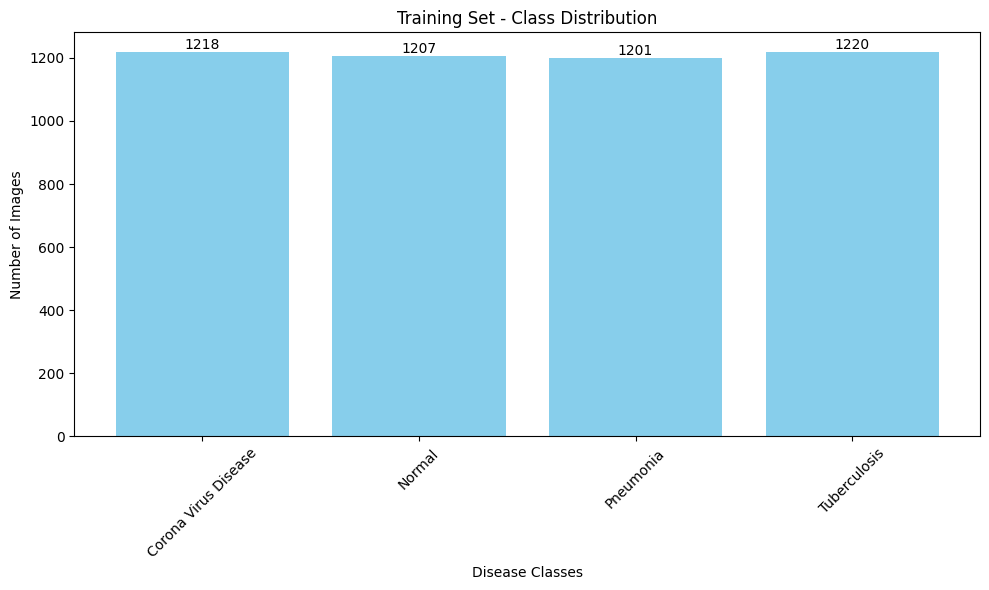


📊 Validation Set Class Distribution:
   Corona Virus Disease: 406 images
   Normal: 402 images
   Pneumonia: 406 images
   Tuberculosis: 406 images


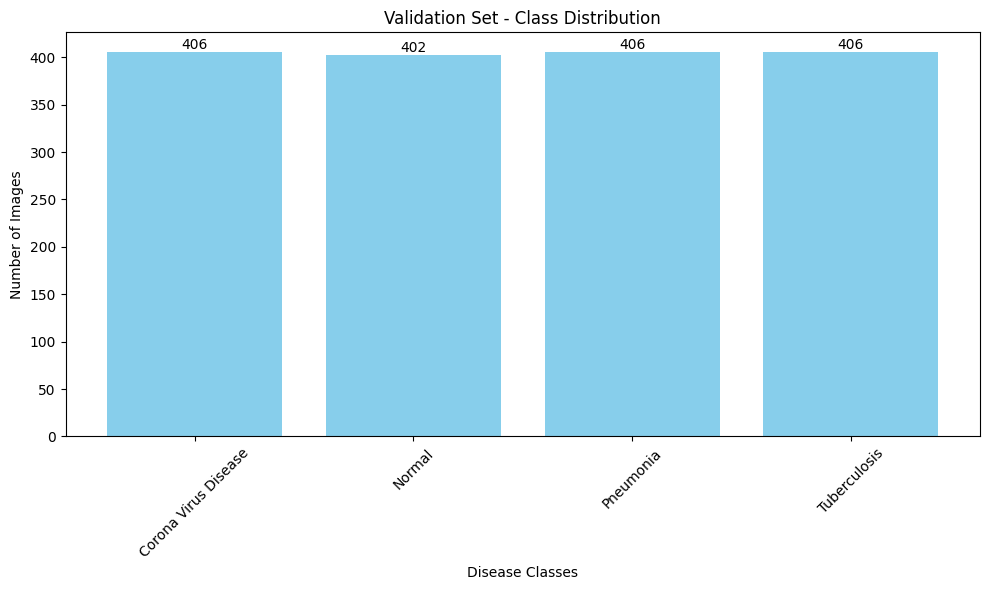


📊 Test Set Class Distribution:
   Corona Virus Disease: 407 images
   Normal: 404 images
   Pneumonia: 402 images
   Tuberculosis: 408 images


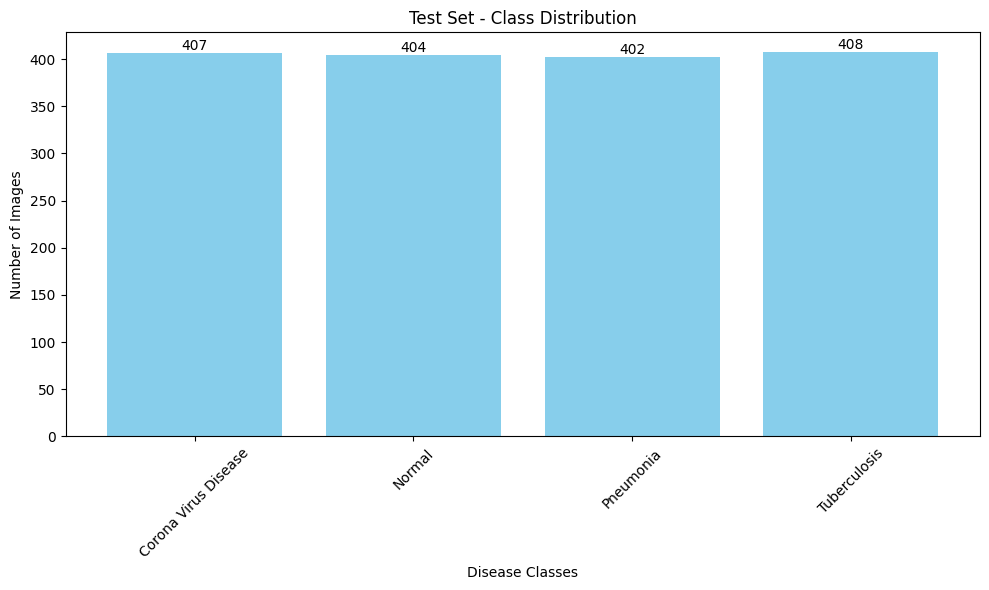

In [8]:
train_counts, class_names = analyze_dataset(train_path, "Training Set")
val_counts, _ = analyze_dataset(val_path, "Validation Set")
test_counts, _ = analyze_dataset(test_path, "Test Set")

In [9]:
def visualize_attention_maps(model, dataset, class_names, num_samples=4):
    """Visualize attention maps for sample images"""
    print("\n👁️ Visualizing Attention Maps...")
    
    plt.figure(figsize=(15, 10))
    
    # Get a batch of images
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            # Get the image
            img = images[i].numpy()
            
            # Get true label
            true_label = class_names[tf.argmax(labels[i])]
            
            # Create a model that outputs both predictions and attention maps
            attention_model = tf.keras.Model(
                inputs=model.input,
                outputs=[model.output, model.get_layer('attention_map').output]
            )
            
            # Get prediction and attention map
            img_expanded = tf.expand_dims(img, axis=0)
            prediction, attention_map = attention_model.predict(img_expanded, verbose=0)
            
            # Get predicted class
            predicted_class = class_names[tf.argmax(prediction[0])]
            confidence = np.max(prediction[0])
            
            # Plot original image
            plt.subplot(num_samples, 3, i*3 + 1)
            plt.imshow(img.astype("uint8"))
            plt.title(f"Original\nTrue: {true_label}")
            plt.axis('off')
            
            # Plot attention map
            plt.subplot(num_samples, 3, i*3 + 2)
            att_map = attention_map[0].squeeze()
            plt.imshow(att_map, cmap='hot')
            plt.title(f"Attention Map\nHeatmap")
            plt.colorbar()
            plt.axis('off')
            
            # Plot attention overlaid on image
            plt.subplot(num_samples, 3, i*3 + 3)
            plt.imshow(img.astype("uint8"), alpha=0.7)
            plt.imshow(att_map, cmap='hot', alpha=0.3)
            plt.title(f"Attention Overlay\nPred: {predicted_class} ({confidence:.2%})")
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [10]:
def load_datasets():
    """Load training, validation and test datasets"""
    
    # Load datasets using image_dataset_from_directory
    training_set = tf.keras.utils.image_dataset_from_directory(
        train_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    validation_set = tf.keras.utils.image_dataset_from_directory(
        val_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    test_set = tf.keras.utils.image_dataset_from_directory(
        test_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=False,  # Important for evaluation
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )
    
    return training_set, validation_set, test_set

In [11]:
training_set, validation_set, test_set = load_datasets()
    
# Display dataset information
print(f"📁 Training batches: {len(training_set)}")
print(f"📁 Validation batches: {len(validation_set)}")
print(f"📁 Test batches: {len(test_set)}")

Found 4846 files belonging to 4 classes.


I0000 00:00:1772517701.441597      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772517701.442993      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1620 files belonging to 4 classes.
Found 1621 files belonging to 4 classes.
📁 Training batches: 152
📁 Validation batches: 51
📁 Test batches: 51


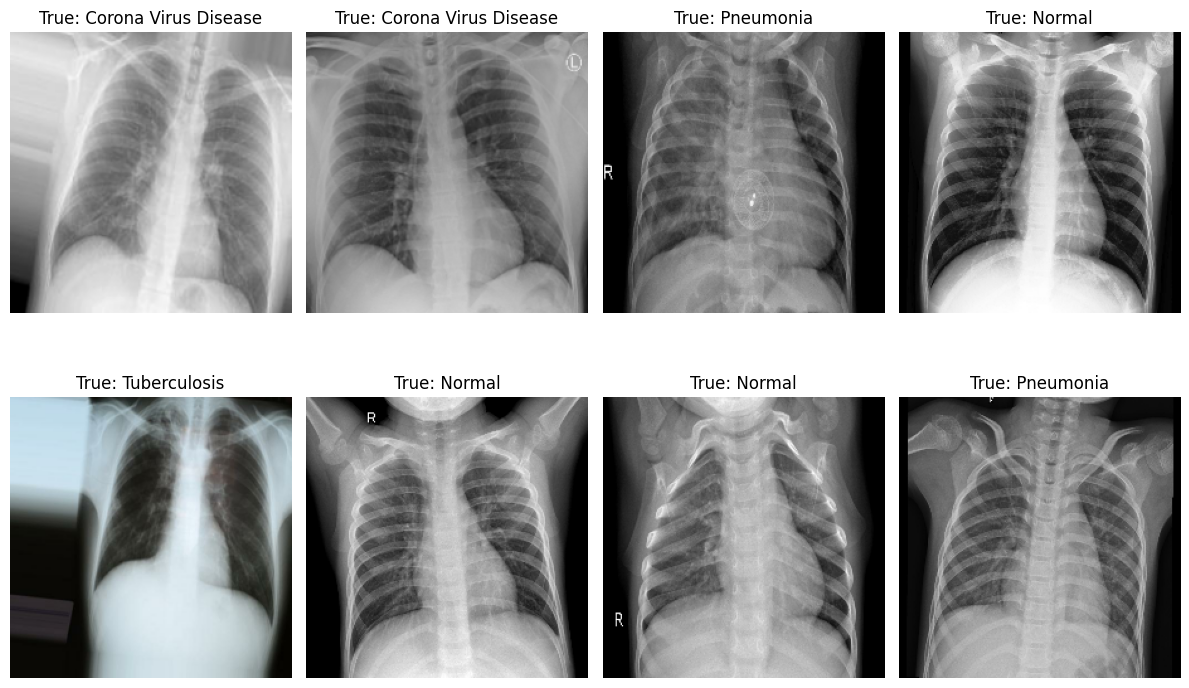

In [12]:
 # Plot sample images
plot_sample_images(training_set, class_names)

In [13]:
@tf.keras.utils.register_keras_serializable()
class ChannelMean(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=3, keepdims=True)


@tf.keras.utils.register_keras_serializable()
class ChannelMax(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=3, keepdims=True)

In [14]:
# -------------------------------
# Hybrid Model Architecture - CNN + Attention
# -------------------------------
def create_cnn_feature_extractor():
    """Create CNN feature extractor (EfficientNetB0)"""
    print(f"\n🛠️ Creating CNN Feature Extractor: {CONFIG['base_cnn']}...")
    
    if CONFIG['base_cnn'] == 'EfficientNetB0':
        base_model = tf.keras.applications.EfficientNetB0(
            input_shape=(*CONFIG['image_size'], 3),
            include_top=False,
            weights='imagenet'
        )
        preprocess_input = tf.keras.applications.efficientnet.preprocess_input
    elif CONFIG['base_cnn'] == 'MobileNetV2':
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=(*CONFIG['image_size'], 3),
            include_top=False,
            weights='imagenet'
        )
        preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
    elif CONFIG['base_cnn'] == 'ResNet50':
        base_model = tf.keras.applications.ResNet50(
            input_shape=(*CONFIG['image_size'], 3),
            include_top=False,
            weights='imagenet'
        )
        preprocess_input = tf.keras.applications.resnet.preprocess_input
    else:
        raise ValueError(f"Unsupported CNN: {CONFIG['base_cnn']}")
    
    # Freeze the feature extractor
    base_model.trainable = False
    
    print(f"✅ {CONFIG['base_cnn']} feature extractor loaded with ImageNet weights")
    print(f"📊 Feature extractor layers: {len(base_model.layers)}")
    print(f"🔒 Feature extractor trainable: {base_model.trainable}")
    
    return base_model, preprocess_input

In [15]:
def create_channel_attention_module(input_tensor, reduction_ratio=8):
    """Create Channel Attention Module (CBAM-style)"""
    channel = input_tensor.shape[-1]
    
    # Global Average Pooling
    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)
    avg_pool = tf.keras.layers.Reshape((1, 1, channel))(avg_pool)
    
    # Global Max Pooling
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(input_tensor)
    max_pool = tf.keras.layers.Reshape((1, 1, channel))(max_pool)
    
    # Shared MLP
    shared_mlp = tf.keras.Sequential([
        tf.keras.layers.Dense(channel // reduction_ratio, activation='relu'),
        tf.keras.layers.Dense(channel, activation='sigmoid')
    ])
    
    avg_out = shared_mlp(avg_pool)
    max_out = shared_mlp(max_pool)
    
    # Combine attention maps
    channel_attention = tf.keras.layers.Add()([avg_out, max_out])
    channel_attention = tf.keras.layers.Activation('sigmoid')(channel_attention)
    
    # Apply attention
    output = tf.keras.layers.multiply([input_tensor, channel_attention])
    
    return output

In [16]:
def create_spatial_attention_module(input_tensor):

    avg_pool = ChannelMean()(input_tensor)
    max_pool = ChannelMax()(input_tensor)

    concat = tf.keras.layers.Concatenate(axis=3)([avg_pool, max_pool])

    spatial_attention = tf.keras.layers.Conv2D(
        filters=1,
        kernel_size=(7, 7),
        padding='same',
        activation='sigmoid'
    )(concat)

    output = tf.keras.layers.Multiply()([input_tensor, spatial_attention])

    return output

In [17]:
def create_attention_module(input_tensor, attention_type='cbam'):
    """Create attention module (CBAM or simple attention)"""
    print(f"\n🎯 Creating {attention_type.upper()} Attention Module...")
    
    if attention_type == 'cbam':
        # CBAM: Convolutional Block Attention Module
        # Channel Attention
        x = create_channel_attention_module(input_tensor)
        # Spatial Attention
        x = create_spatial_attention_module(x)
        
    elif attention_type == 'simple':
        # Simple attention mechanism
        attention_weights = tf.keras.layers.Conv2D(1, (1, 1), padding='same', 
                                                  activation='sigmoid',
                                                  name='attention_map')(input_tensor)
        x = tf.keras.layers.multiply([input_tensor, attention_weights])
        
    else:
        raise ValueError(f"Unsupported attention type: {attention_type}")
    
    return x

In [18]:
def create_hybrid_model(attention_type='cbam'):
    """Create hybrid CNN + Attention model"""
    print(f"\n🏗️ Building Hybrid CNN + Attention Model...")
    print(f"   CNN Feature Extractor: {CONFIG['base_cnn']}")
    print(f"   Attention Mechanism: {attention_type.upper()}")
    
    # Input layer
    inputs = tf.keras.Input(shape=(*CONFIG['image_size'], 3))
    
    # Load CNN feature extractor
    base_model, preprocess_input = create_cnn_feature_extractor()
    
    # Preprocessing
    x = preprocess_input(inputs)
    
    # Feature extraction
    x = base_model(x, training=False)
    
    print(f"   Feature extractor output shape: {x.shape}")
    
    # Apply attention mechanism
    x = create_attention_module(x, attention_type)
    
    # Global pooling
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    # Additional dense layers
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    # Output layer
    outputs = tf.keras.layers.Dense(CONFIG['num_classes'], activation='softmax')(x)
    
    # Create model
    model = tf.keras.Model(inputs, outputs, name=f"Hybrid_{CONFIG['base_cnn']}_{attention_type}")
    
    return model

In [19]:
def compile_model(model):
    """Compile the hybrid model"""
    print("\n⚙️ Compiling Hybrid Model...")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.F1Score(name='f1_score', average='weighted')
        ]
    )
    
    return model

In [20]:
# Step 3: Model Creation
print("\n3️⃣ STEP 3: Hybrid Model Creation")
print("-" * 30)
print("🔧 Model Components:")
print("   1. CNN Feature Extractor (frozen)")
print("   2. Attention Mechanism")
print("   3. Dense Classifier Head")

# Create hybrid model with CBAM attention
model = create_hybrid_model(attention_type='cbam')
model = compile_model(model)


3️⃣ STEP 3: Hybrid Model Creation
------------------------------
🔧 Model Components:
   1. CNN Feature Extractor (frozen)
   2. Attention Mechanism
   3. Dense Classifier Head

🏗️ Building Hybrid CNN + Attention Model...
   CNN Feature Extractor: EfficientNetB0
   Attention Mechanism: CBAM

🛠️ Creating CNN Feature Extractor: EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB0 feature extractor loaded with ImageNet weights
📊 Feature extractor layers: 238
🔒 Feature extractor trainable: False
   Feature extractor output shape: (None, 7, 7, 1280)

🎯 Creating CBAM Attention Module...

⚙️ Compiling Hybrid Model...


In [21]:
# Display model architecture
print("📐 Model Architecture Summary:")
model.summary()

📐 Model Architecture Summary:


Model: "Hybrid_EfficientNetB0_cbam"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1,      │          0 │ global_max_pooli… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 1, 1,      │    411,040 │ reshape[0][0],    │
│ (Sequential)        │ 1280)             │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1,      │          0 │ sequential[0][0], │
│                     │ 1280)             │            │ sequential[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1, 1,      │          0 │ add[0][0]         │
│ (Activation)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ efficientnetb0[0… │
│                     │ 1280)             │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_mean        │ (None, 7, 7, 1)   │          0 │ multiply[0][0]    │
│ (ChannelMean)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_max         │ (None, 7, 7, 1)   │          0 │ multiply[0][0]    │
│ (ChannelMax)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 2)   │          0 │ channel_mean[0][… │
│ (Concatenate)       │                   │            │ channel_max[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 7, 7,      │          0 │ multiply[0][0],   │
│ (Multiply)          │ 1280)             │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,284,394 (20.16 MB)

 Trainable params: 1,233,287 (4.70 MB)

 Non-trainable params: 4,051,107 (15.45 MB)

Phase 1 Training

In [22]:
# -------------------------------
# Training Configuration
# -------------------------------
def get_training_callbacks():
    """Get training callbacks for hybrid model"""
    callbacks = [
        # Early stopping
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=1e-7,
            verbose=1
        ),
        
        # Save best model
        tf.keras.callbacks.ModelCheckpoint(
            'hybrid_model_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # TensorBoard for visualization
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs/hybrid_model',
            histogram_freq=1
        ),
        
        # Custom callback to track attention weights
        tf.keras.callbacks.LambdaCallback(
            on_epoch_end=lambda epoch, logs: print(f"   Epoch {epoch+1}: Attentive training in progress...")
        )
    ]
    
    return callbacks

In [23]:
callbacks = get_training_callbacks()

In [24]:
history = model.fit(
        training_set,
        epochs=CONFIG['epochs'],
        validation_data=validation_set,
        callbacks=callbacks,
        verbose=1
    )

Epoch 1/35


I0000 00:00:1772517721.143362      85 service.cc:152] XLA service 0x7b7048119990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772517721.143404      85 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772517721.143410      85 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772517723.930406      85 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-03 06:02:11.213793: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:02:11.357889: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:02:11.699086: E external/local_xl

151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5989 - f1_score: 0.5940 - loss: 1.0078 - precision: 0.6630 - recall: 0.5390

2026-03-03 06:02:48.286704: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:02:48.425189: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:02:48.742136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:02:48.883246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:02:49.601967: E external/local_xla/xla/stream_

152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.5998 - f1_score: 0.5949 - loss: 1.0057 - precision: 0.6637 - recall: 0.5400

2026-03-03 06:03:16.683378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:03:16.824380: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:03:17.154800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:03:17.296844: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:03:17.991883: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.90741, saving model to hybrid_model_best.keras
   Epoch 1: Attentive training in progress...
152/152 ━━━━━━━━━━━━━━━━━━━━ 96s 415ms/step - accuracy: 0.6007 - f1_score: 0.5958 - loss: 1.0037 - precision: 0.6645 - recall: 0.5410 - val_accuracy: 0.9074 - val_f1_score: 0.9072 - val_loss: 0.2878 - val_precision: 0.9197 - val_recall: 0.8840 - learning_rate: 5.0000e-04
Epoch 2/35
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8582 - f1_score: 0.8581 - loss: 0.3567 - precision: 0.8711 - recall: 0.8461
Epoch 2: val_accuracy improved from 0.90741 to 0.93272, saving model to hybrid_model_best.keras
   Epoch 2: Attentive training in progress...
152/152 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - accuracy: 0.8582 - f1_score: 0.8581 - loss: 0.3567 - precision: 0.8712 - recall: 0.8461 - val_accuracy: 0.9327 - val_f1_score: 0.9327 - val_loss: 0.1888 - val_precision: 0.9347 - val_recall: 0.9284 - learning_rate: 5.0000e-04
Epoch 3/35
152/152 ━━━━━━━━━━━━

In [25]:
# Save the final model
model.save('hybrid_cnn_attention_final_model.h5')
model.save('hybrid_cnn_attention_final_model.keras')

In [26]:
# Save training history
with open('hybrid_cnn_attention_training_history.pkl', 'wb') as f:
        history_data = {
            'history': history.history,
            'config': CONFIG,
            'architecture': 'CNN + Attention Hybrid'
        }
        pickle.dump(history_data, f)
    
print("✅ Hybrid model saved as 'hybrid_cnn_attention_final_model.h5'")
print("✅ Training history saved as 'hybrid_cnn_attention_training_history.pkl'")

✅ Hybrid model saved as 'hybrid_cnn_attention_final_model.h5'
✅ Training history saved as 'hybrid_cnn_attention_training_history.pkl'


# Model Evaluation

In [27]:
def plot_training_history(history):
    """Plot comprehensive training history"""
    print("\n📈 Plotting Training History...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[0, 2].plot(history.history['precision'], label='Training Precision', linewidth=2, color='blue')
    axes[0, 2].plot(history.history['val_precision'], label='Validation Precision', linewidth=2, color='red')
    axes[0, 2].set_title('Model Precision')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Precision')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 0].plot(history.history['recall'], label='Training Recall', linewidth=2, color='blue')
    axes[1, 0].plot(history.history['val_recall'], label='Validation Recall', linewidth=2, color='red')
    axes[1, 0].set_title('Model Recall')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Recall')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # F1-Score
    axes[1, 1].plot(history.history['f1_score'], label='Training F1-Score', linewidth=2, color='blue')
    axes[1, 1].plot(history.history['val_f1_score'], label='Validation F1-Score', linewidth=2, color='red')
    axes[1, 1].set_title('Model F1-Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1-Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Learning Rate
    if 'lr' in history.history:
        axes[1, 2].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='green')
        axes[1, 2].set_title('Learning Rate')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('Learning Rate')
        axes[1, 2].set_yscale('log')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle(f'Hybrid CNN + Attention Model Training History', fontsize=16)
    plt.tight_layout()
    plt.show()


📈 Plotting Training History...


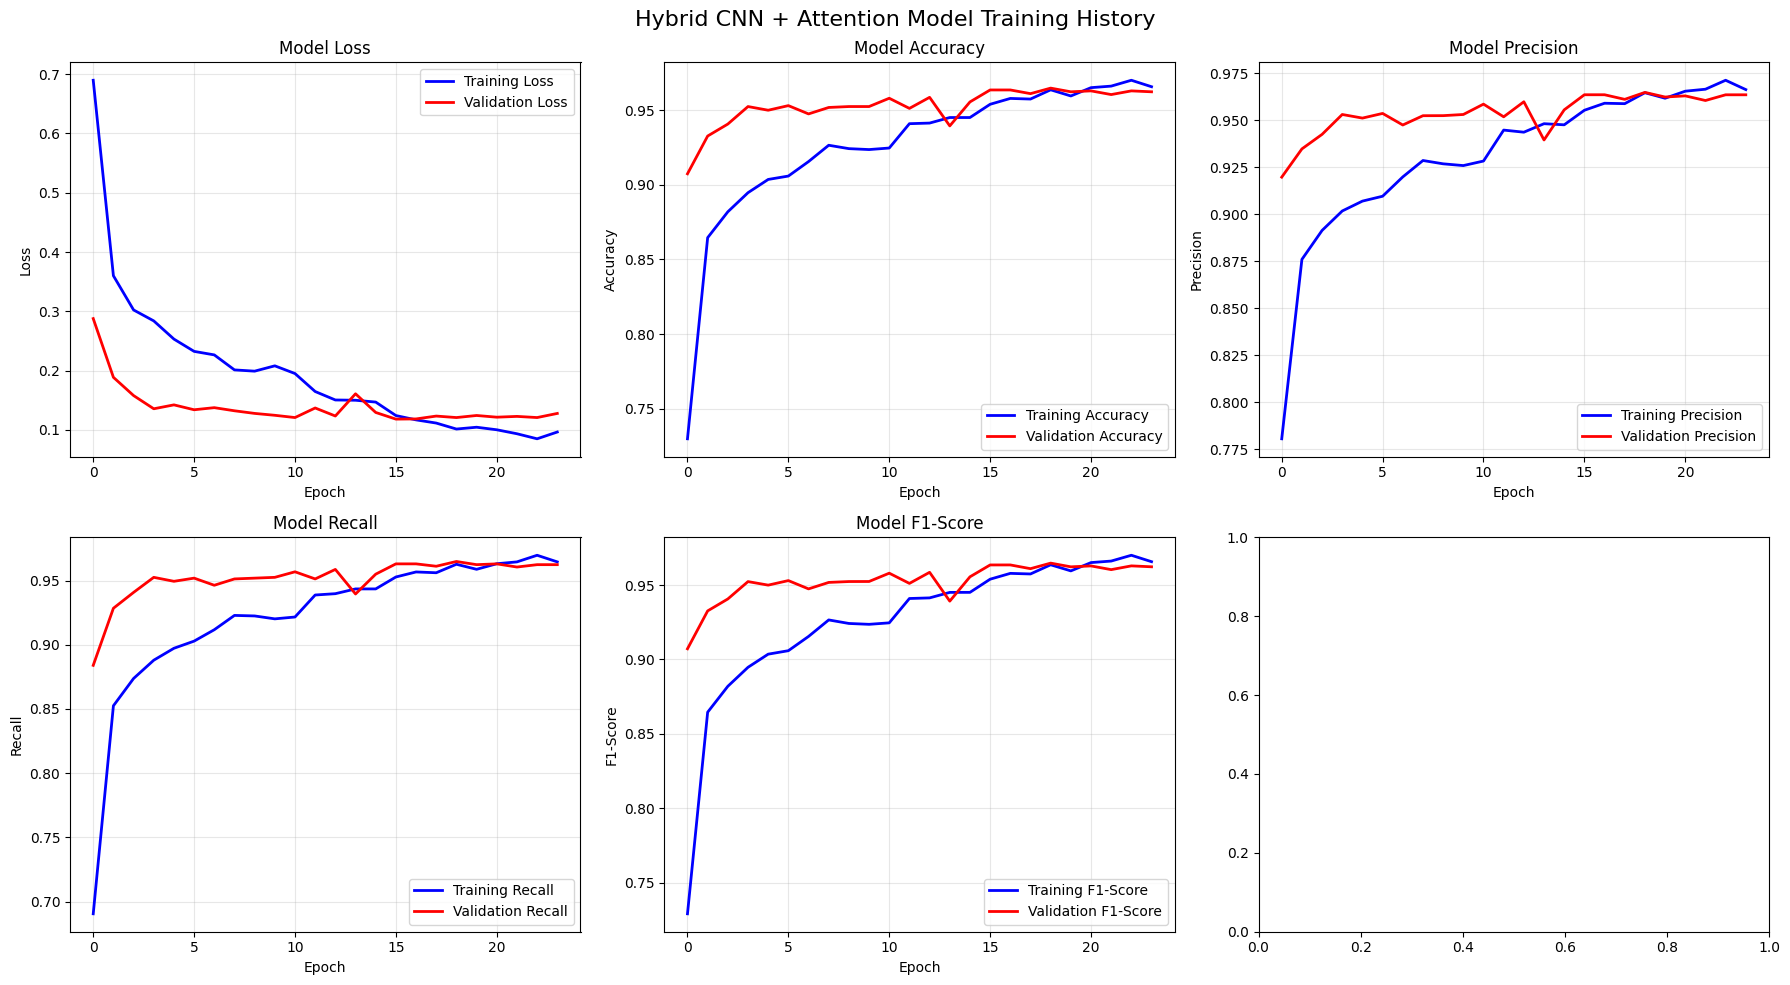

In [28]:
plot_training_history(history)

In [29]:
# Step 7: Attention Visualization
print("\n7️⃣ STEP 7: Attention Mechanism Visualization")
print("-" * 30)
    
# Visualize attention maps (if using simple attention)
try:
    visualize_attention_maps(model, validation_set, class_names, num_samples=3)
except:
    print("⚠️ Attention visualization not available for this attention type")
    print("   Try using 'simple' attention type for visualization")


7️⃣ STEP 7: Attention Mechanism Visualization
------------------------------

👁️ Visualizing Attention Maps...
⚠️ Attention visualization not available for this attention type
   Try using 'simple' attention type for visualization


<Figure size 1500x1000 with 0 Axes>

In [30]:
# -------------------------------
# Evaluation Functions
# -------------------------------
def evaluate_model(model, test_set, class_names):
    """Comprehensive model evaluation"""
    print("\n🧪 Evaluating Hybrid Model Performance...")
    
    # Basic evaluation
    print("📊 Running Model Evaluation...")
    evaluation_results = model.evaluate(test_set, verbose=1)
    
    # Create a dictionary with metric names and values
    metric_names = ['loss', 'accuracy', 'precision', 'recall', 'f1_score']
    eval_dict = dict(zip(metric_names, evaluation_results))
    
    print("\n📋 Evaluation Results:")
    for metric, value in eval_dict.items():
        print(f"   {metric.capitalize()}: {value:.4f}")
    
    # Predictions for detailed analysis
    print("\n🔍 Generating Predictions...")
    y_true = []
    y_pred = []
    y_probs = []
    
    for images, labels in test_set:
        # Get true labels
        true_labels = tf.argmax(labels, axis=1)
        y_true.extend(true_labels.numpy())
        
        # Get predictions
        predictions = model.predict(images, verbose=0)
        pred_labels = tf.argmax(predictions, axis=1)
        y_pred.extend(pred_labels.numpy())
        y_probs.extend(predictions)
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)
    
    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    plot_confusion_matrix(y_true, y_pred, class_names)
    
    # Plot probability distributions
    plot_probability_distributions(y_probs, class_names)
    
    return y_true, y_pred, y_probs, eval_dict

In [31]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot detailed confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    
    # Plot regular confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix\n(Counts)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    # Calculate normalized confusion matrix
    plt.subplot(1, 2, 2)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='viridis',
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix\n(Normalized)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    plt.tight_layout()
    plt.show()

In [32]:
def plot_probability_distributions(y_probs, class_names):
    """Plot probability distributions for each class"""
    print("\n📊 Plotting Prediction Probability Distributions...")
    
    num_classes = len(class_names)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i in range(num_classes):
        probs = y_probs[:, i]
        axes[i].hist(probs, bins=20, alpha=0.7, color='teal', edgecolor='black')
        axes[i].set_xlabel('Prediction Probability')
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'Class: {class_names[i]}')
        axes[i].grid(True, alpha=0.3)
        
        # Add statistics
        mean_prob = np.mean(probs)
        std_prob = np.std(probs)
        axes[i].axvline(mean_prob, color='red', linestyle='--', label=f'Mean: {mean_prob:.3f}')
        axes[i].axvline(mean_prob + std_prob, color='orange', linestyle=':', alpha=0.7)
        axes[i].axvline(mean_prob - std_prob, color='orange', linestyle=':', alpha=0.7)
        axes[i].legend()
    
    plt.suptitle('Prediction Probability Distributions per Class', fontsize=14)
    plt.tight_layout()
    plt.show()


🧪 Evaluating Hybrid Model Performance...
📊 Running Model Evaluation...
49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9651 - f1_score: 0.9728 - loss: 0.0838 - precision: 0.9650 - recall: 0.9649

2026-03-03 06:12:10.953974: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:12:11.096528: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:12:11.430309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:12:11.572740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:12:12.269987: E external/local_xla/xla/stream_

51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 325ms/step - accuracy: 0.9649 - f1_score: 0.9721 - loss: 0.0846 - precision: 0.9648 - recall: 0.9647

📋 Evaluation Results:
   Loss: 0.0966
   Accuracy: 0.9618
   Precision: 0.9617
   Recall: 0.9611
   F1_score: 0.9617

🔍 Generating Predictions...

📋 Detailed Classification Report:
                      precision    recall  f1-score   support

Corona Virus Disease       0.98      0.97      0.98       407
              Normal       0.95      0.94      0.95       404
           Pneumonia       0.93      0.94      0.94       402
        Tuberculosis       0.98      0.99      0.99       408

            accuracy                           0.96      1621
           macro avg       0.96      0.96      0.96      1621
        weighted avg       0.96      0.96      0.96      1621



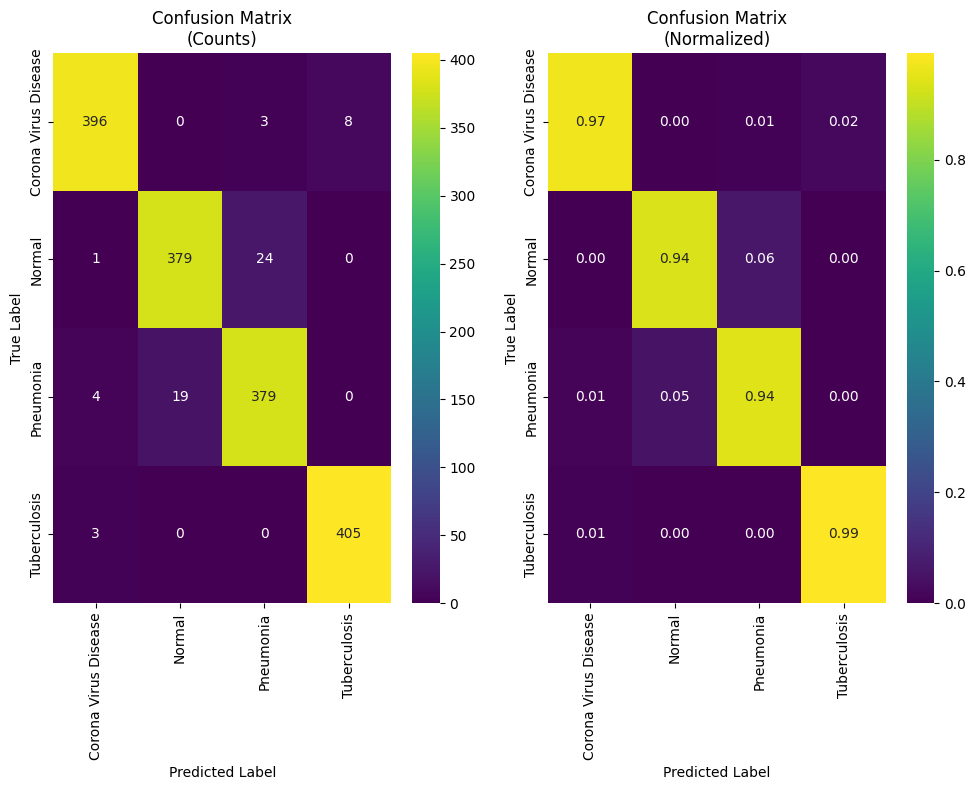


📊 Plotting Prediction Probability Distributions...


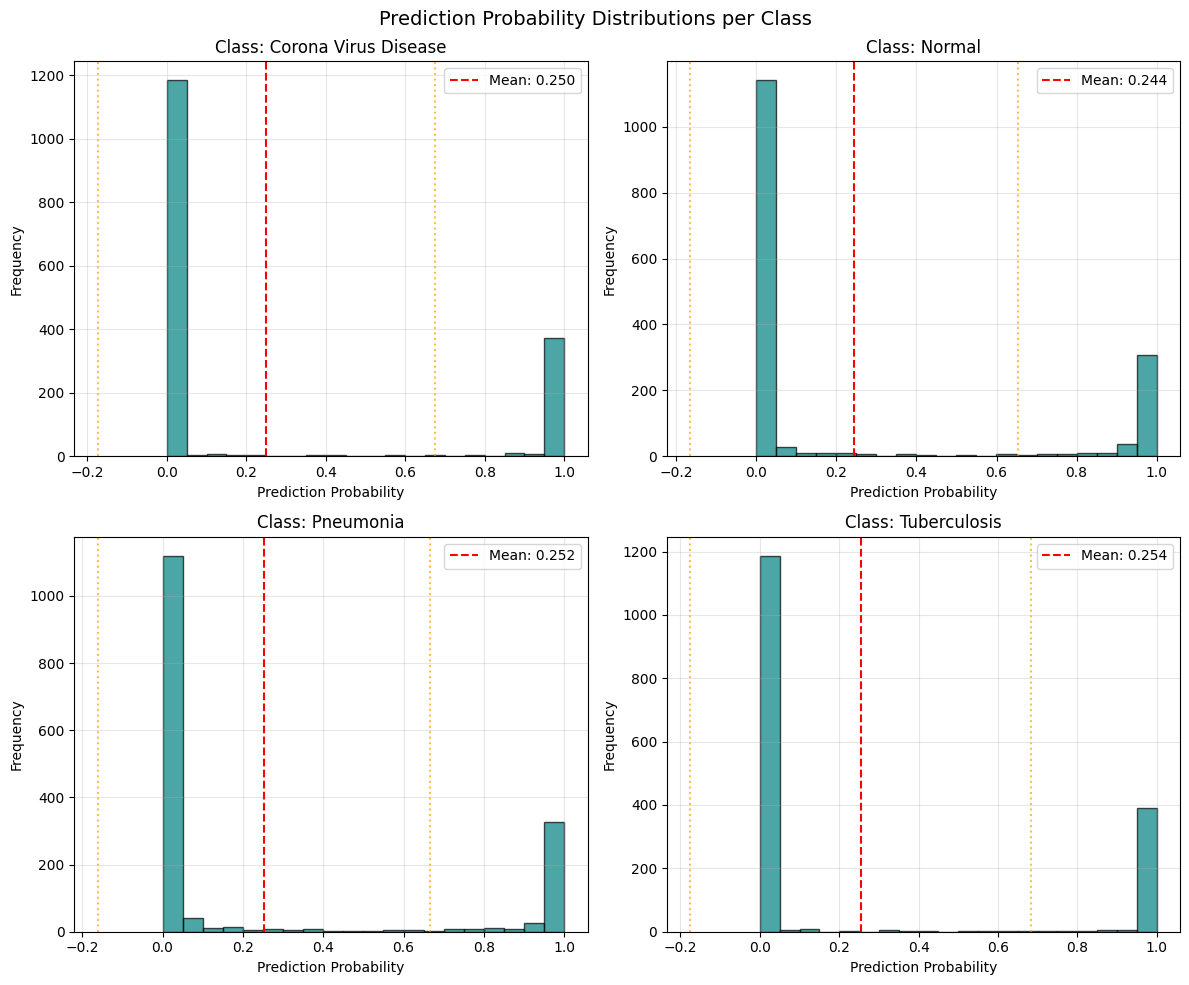

In [33]:
y_true, y_pred, y_probs, eval_results = evaluate_model(model, test_set, class_names)

In [34]:
print("🎉 Hybrid CNN + Attention Model Training Completed Successfully!")
print(f"📊 Final Test Accuracy: {eval_results['accuracy']:.2%}")
print(f"📊 Final Test F1-Score: {eval_results['f1_score']:.2%}")

🎉 Hybrid CNN + Attention Model Training Completed Successfully!
📊 Final Test Accuracy: 96.18%
📊 Final Test F1-Score: 96.17%


In [35]:
# Display model summary
print(f"\n📋 Hybrid Model Summary:")
print(f"   CNN Backbone: {CONFIG['base_cnn']}")
print(f"   Attention Type: CBAM (Channel & Spatial)")
print(f"   Training Epochs: {len(history.history['loss'])}")
print(f"   Final Learning Rate: {model.optimizer.learning_rate.numpy():.2e}")


📋 Hybrid Model Summary:
   CNN Backbone: EfficientNetB0
   Attention Type: CBAM (Channel & Spatial)
   Training Epochs: 24
   Final Learning Rate: 6.25e-05


In [36]:
def predict_with_attention(model, image_path, class_names):
    """Predict a single image with attention visualization"""
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=CONFIG['image_size'])
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    
    # Preprocess based on CNN type
    if CONFIG['base_cnn'] == 'EfficientNetB0':
        img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    elif CONFIG['base_cnn'] == 'MobileNetV2':
        img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    elif CONFIG['base_cnn'] == 'ResNet50':
        img_array = tf.keras.applications.resnet.preprocess_input(img_array)
    
    img_array = tf.expand_dims(img_array, 0)  # Create batch dimension
    
    # Get predictions
    predictions = model.predict(img_array)
    predicted_class_idx = tf.argmax(predictions[0]).numpy()
    predicted_class = class_names[predicted_class_idx]
    confidence = np.max(predictions[0])
    
    # Create attention visualization
    print(f"\n🔍 Attention-based Prediction Analysis:")
    print(f"   Predicted: {predicted_class}")
    print(f"   Confidence: {confidence:.2%}")
    
    # Plot the image with prediction
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Input Image\nTrue: {os.path.basename(os.path.dirname(image_path))}")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    # Create a bar plot of probabilities
    colors = ['teal' if i == predicted_class_idx else 'lightgray' for i in range(len(class_names))]
    plt.barh(class_names, predictions[0], color=colors)
    plt.xlabel('Probability')
    plt.title(f'Class Probabilities\nPredicted: {predicted_class}')
    plt.xlim([0, 1])
    
    plt.subplot(1, 3, 3)
    # Show attention text
    plt.text(0.1, 0.8, f'Hybrid CNN + Attention Model', fontsize=12, fontweight='bold')
    plt.text(0.1, 0.6, f'CNN Backbone: {CONFIG["base_cnn"]}', fontsize=10)
    plt.text(0.1, 0.5, f'Prediction: {predicted_class}', fontsize=10, color='teal')
    plt.text(0.1, 0.4, f'Confidence: {confidence:.2%}', fontsize=10)
    plt.text(0.1, 0.3, f'Attention Focus:', fontsize=10, fontweight='bold')
    plt.text(0.1, 0.2, f'- Disease patterns', fontsize=9)
    plt.text(0.1, 0.1, f'- Texture features', fontsize=9)
    plt.text(0.1, 0.0, f'- Anatomical regions', fontsize=9)
    plt.axis('off')
    
    plt.suptitle(f'Hybrid Model Prediction with Attention Mechanism', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return predicted_class, confidence

🔍 Testing hybrid model prediction on: 00030389_012.png


2026-03-03 06:12:44.149200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:12:44.284947: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:12:44.956237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:12:45.092690: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step

🔍 Attention-based Prediction Analysis:
   Predicted: Corona Virus Disease
   Confidence: 100.00%


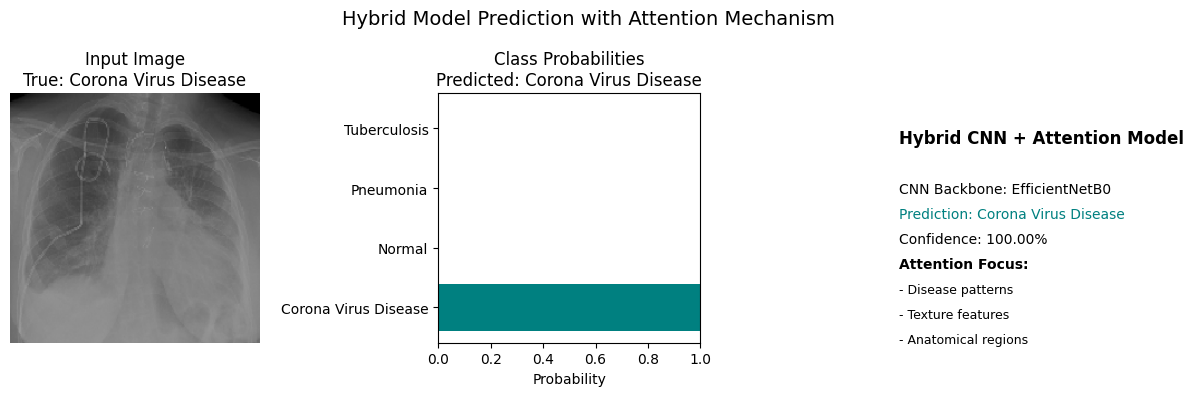

In [37]:
# Find a sample image from test set for demonstration
test_images_dir = os.path.join(test_path, class_names[0])
if os.path.exists(test_images_dir):
    sample_images = os.listdir(test_images_dir)
    if sample_images:
        sample_image_path = os.path.join(test_images_dir, sample_images[0])
print(f"🔍 Testing hybrid model prediction on: {sample_images[0]}")
predicted_class, confidence = predict_with_attention(model, sample_image_path, class_names)

In [38]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
import numpy as np
import os

image_path = "/kaggle/input/datasets/shaswatam/epics-lung-disease-dataset/new-lung-disease-dataset/test/Pneumonia/031.jpeg"
img = tf.keras.utils.load_img(image_path, target_size=(224,224))
img

x = tf.keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
x.shape

(1, 224, 224, 3)

In [39]:
pred = model.predict(x)

class_name=['Corona Virus Disease','Normal','Pneumonia', 'Tuberculosis']
result_index = np.argmax(pred)
print("Model Prediction: ", class_name[result_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Model Prediction:  Pneumonia
